### Parser Table: Paso a Paso

En este notebook vamos a agarrar la foto de un tablero y la vamos a procesar hasta dejarla plana, orientada y con su grilla bien detectada. Vamos a ir viendo el resultado en cada paso para entender qué está pasando paso a paso.

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar_imagen(img, titulo="Imagen"):
    """Helper para plotear rápido con matplotlib en el notebook."""
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV usa BGR, plt usa RGB
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

#### 1. Cargar la imagen y buscar los bordes
Primero cargamos la foto en escala de grises. Para encontrar el tablero, usamos el detector de bordes de Canny. Antes le pasamos un "blur" (desenfoque) para matar el ruido chiquito y que no nos detecte basurita como si fueran bordes.

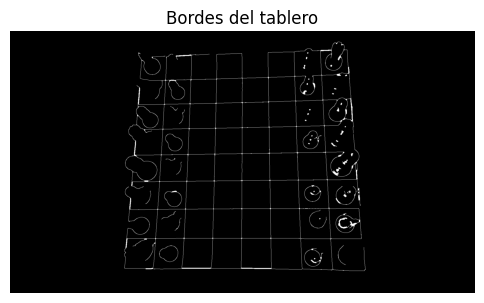

In [12]:
ruta = "../../../data/raw/tablero_horizontal.jpg"
img_original = cv2.imread(ruta)
img_gris = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(img_gris, (5, 5), 0)
bordes = cv2.Canny(blur, 50, 150)

kernel = np.ones((5, 5), np.uint8)
bordes_cerrados = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel)

mostrar_imagen(bordes_cerrados, "Bordes del tablero")

#### 2. Encontrar las 4 esquinas
Ya tenemos las líneas blancas sobre fondo negro. Ahora buscamos el contorno más grande de la imagen (que debería ser el tablero) y lo aproximamos a un polígono de 4 lados para sacar las esquinas exactas.

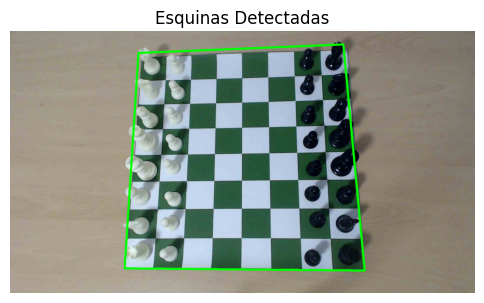

In [13]:
contornos, _ = cv2.findContours(bordes_cerrados, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos = sorted(contornos, key=cv2.contourArea, reverse=True)

# Agarramos el contorno más grande y lo simplificamos a 4 puntos
hull = cv2.convexHull(contornos[0])
perimetro = cv2.arcLength(hull, True)
esquinas = cv2.approxPolyDP(hull, 0.04 * perimetro, True)

# Dibujamos las esquinas para ver si le pegamos
img_debug = img_original.copy()
cv2.drawContours(img_debug, [esquinas], -1, (0, 255, 0), 7)

mostrar_imagen(img_debug, "Esquinas Detectadas")

#### 3. Corrección de perspectiva
La foto seguro está sacada en ángulo. Como ya tenemos las 4 esquinas y sabemos que un tablero es un cuadrado perfecto, usamos una "Homografía" (`getPerspectiveTransform`). Esto estira la imagen y la aplana.

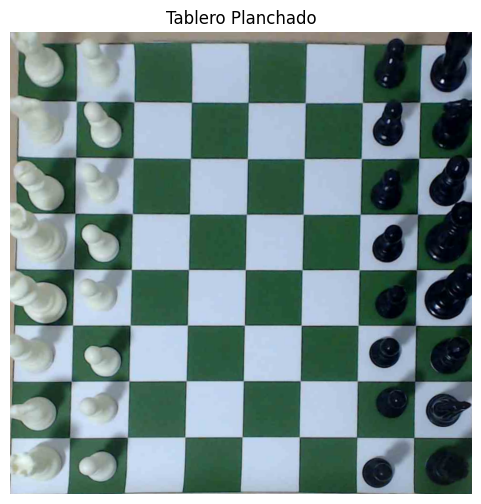

In [14]:
def sort_corners(pts):
    """Ordena 4 puntos en: arriba-izq, abajo-izq, abajo-der, arriba-der."""
    pts = pts.reshape(4, 2).astype(np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).ravel()
    return np.array([pts[np.argmin(s)], pts[np.argmax(d)], pts[np.argmax(s)], pts[np.argmin(d)]], dtype=np.float32)


LADO = 800 # Queremos que la imagen final sea de 800x800 píxeles

pts_origen = sort_corners(esquinas)
pts_destino = np.array([[0, 0], [0, LADO], [LADO, LADO], [LADO, 0]], dtype=np.float32)

# Calculamos la matriz de transformación y deformamos la imagen
matriz_H = cv2.getPerspectiveTransform(pts_origen, pts_destino)
tablero_plano = cv2.warpPerspective(img_original, matriz_H, (LADO, LADO))

mostrar_imagen(tablero_plano, "Tablero Planchado")

#### 4. Orientar el tablero
El tablero puede estar rotado. Acá lo pasamos a formato HSV, medimos el brillo en los bordes y lo rotamos para que queden las blancas abajo y las negras arriba (buscando dónde hay más luz o sombra según la lógica del juego).

El tablero estaba mal orientado. Rotación aplicada.


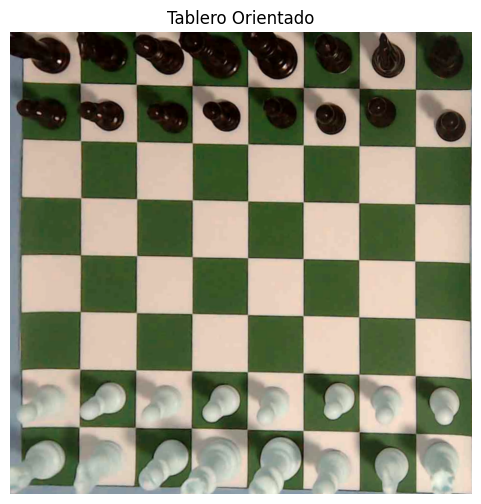

In [15]:
# Trabajamos sobre la imagen ya planchada en HSV
tablero_hsv = cv2.cvtColor(tablero_plano, cv2.COLOR_BGR2HSV)

v = tablero_hsv[:, :, 2]
lado = v.shape[0]
paso = lado // 8
margen = paso // 3  

def medir_brillo(filas, columnas):
    brillo = 0
    for f in filas:
        for c in columnas:
            y1, y2 = f * paso + margen, (f + 1) * paso - margen
            x1, x2 = c * paso + margen, (c + 1) * paso - margen
            brillo += np.mean(v[y1:y2, x1:x2])
    return brillo

todas = range(8)
extremos_ini = [0, 1]
extremos_fin = [6, 7]

# Medimos el brillo en los 4 costados
m_arriba = medir_brillo(extremos_ini, todas)
m_abajo  = medir_brillo(extremos_fin, todas)
m_izq    = medir_brillo(todas, extremos_ini)
m_der    = medir_brillo(todas, extremos_fin)

diff_vert  = abs(m_arriba - m_abajo)
diff_horiz = abs(m_izq - m_der)

# Decidimos la rotación según dónde hay más diferencia de brillo
if diff_vert >= diff_horiz:
    rotacion = None if m_abajo >= m_arriba else cv2.ROTATE_180
else:
    rotacion = cv2.ROTATE_90_CLOCKWISE if m_der >= m_izq else cv2.ROTATE_90_COUNTERCLOCKWISE

if rotacion is not None:
    tablero_hsv = cv2.rotate(tablero_hsv, rotacion)
    print("El tablero estaba mal orientado. Rotación aplicada.")
else:
    print("La orientación estaba bien. No se aplicó rotación.")

tablero_final_rgb = cv2.cvtColor(tablero_hsv, cv2.COLOR_HSV2RGB)
mostrar_imagen(tablero_final_rgb, "Tablero Orientado")

#### 5. Detectar la grilla: Estándar vs Hough
Vamos a comparar qué pasa si simplemente dividimos la imagen de 800x800 por 8 (grilla matemática perfecta) versus el uso de Transformada de Hough que detecta las líneas reales adaptándose a las deformaciones del lente.

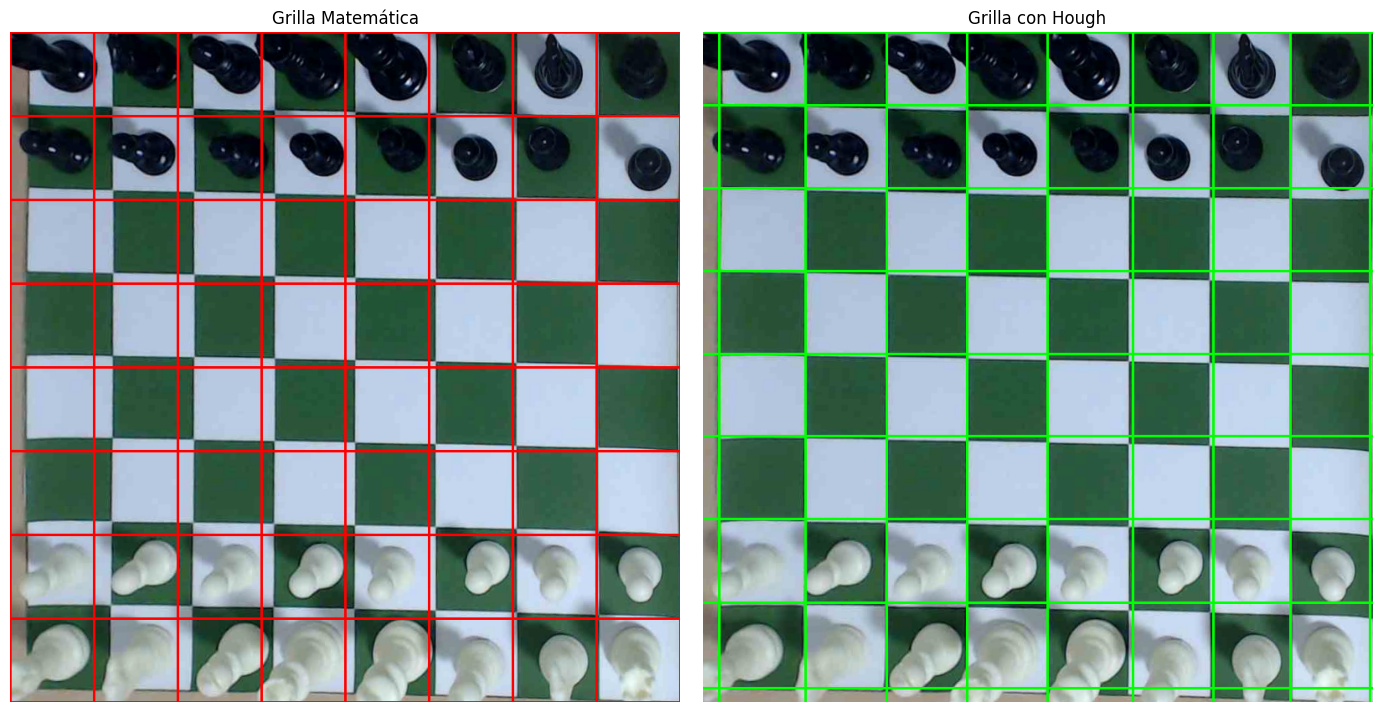

In [16]:
def _unificar_lineas(lineas, umbral_rho=30, umbral_theta=np.pi / 180 * 15):
    lineas_agrupadas = []
    for linea in lineas:
        for rho, theta in linea:
            grupo = None
            for g in lineas_agrupadas:
                for u_rho, u_theta in g:
                    if (abs(u_rho - rho) < umbral_rho and abs(u_theta - theta) < umbral_theta) or \
                       (abs(u_rho + rho) < umbral_rho and abs(u_theta - (theta + np.pi)) % (2 * np.pi) < umbral_theta):
                        grupo = g
                        break
                if grupo: break
            if grupo: grupo.append((rho, theta))
            else: lineas_agrupadas.append([(rho, theta)])
    resultado = []
    for g in lineas_agrupadas:
        g.sort(key=lambda a: a[1])
        resultado.append(g[(len(g) - 1) // 2])
    return np.array([[l] for l in resultado], dtype=np.float32)

def _segmentar_por_angulo(lineas, umbral_theta=np.pi / 180 * 10):
    grupos = []
    for linea in lineas:
        for rho, theta in linea:
            grupo = None
            for g in grupos:
                for _, u_theta in g:
                    if (abs(u_theta - theta) < umbral_theta or abs(u_theta - (theta + np.pi)) % (2 * np.pi) < umbral_theta or
                            abs(u_theta - (np.pi - theta)) < umbral_theta or abs(theta - (np.pi - u_theta)) < umbral_theta):
                        grupo = g
                        break
                if grupo: break
            if grupo: grupo.append((rho, theta))
            else: grupos.append([(rho, theta)])
    grupos = sorted(grupos, key=len, reverse=True)
    return np.array([[l] for l in grupos[0]], dtype=np.float32), np.array([[l] for l in grupos[1]], dtype=np.float32)

def _identificar_horiz_vert(grupo_a, grupo_b):
    ta, tb = np.mean([abs(l[0][1]) for l in grupo_a]), np.mean([abs(l[0][1]) for l in grupo_b])
    return (grupo_a, grupo_b) if abs(ta - np.pi / 2) < abs(tb - np.pi / 2) else (grupo_b, grupo_a)

def _extraer_limites(lineas_horiz, lineas_vert, lado):
    y_pos = sorted({int(round(abs(l[0][0]))) for l in lineas_horiz})
    x_pos = sorted({int(round(abs(l[0][0]))) for l in lineas_vert})
    if not y_pos or y_pos[0] > 30: y_pos.insert(0, 0)
    if not y_pos or y_pos[-1] < lado - 30: y_pos.append(lado)
    if not x_pos or x_pos[0] > 30: x_pos.insert(0, 0)
    if not x_pos or x_pos[-1] < lado - 30: x_pos.append(lado)
    
    def _interpolar_9(pos, l): return [int(round((pos[0] if pos else 0) + i * ((pos[-1] if pos else l) - (pos[0] if pos else 0)) / 8)) for i in range(9)]
    if len(y_pos) != 9: y_pos = _interpolar_9(y_pos, lado)
    if len(x_pos) != 9: x_pos = _interpolar_9(x_pos, lado)
    return y_pos, x_pos

# Hough
gray = tablero_hsv[:, :, 2]
blur = cv2.GaussianBlur(gray, (9, 9), 0)
bin_img = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
v_median = np.median(bin_img)
sigma = 0.33
canny = cv2.Canny(bin_img, int(max(0, (1.0 - sigma) * v_median)), int(min(255, (1.0 + sigma) * v_median)), apertureSize=3)

raw = cv2.HoughLines(canny, rho=1.0, theta=np.pi / 180, threshold=200, lines=np.array([]))
lineas = _unificar_lineas(_unificar_lineas(raw))
grupo_a, grupo_b = _segmentar_por_angulo(lineas)
lineas_horiz, lineas_vert = _identificar_horiz_vert(grupo_a, grupo_b)

y_hough, x_hough = _extraer_limites(lineas_horiz, lineas_vert, LADO)

# Grilla estándar
paso = LADO // 8
y_std = [i * paso for i in range(9)]
x_std = [i * paso for i in range(9)]



img_hough = tablero_final_rgb.copy()
img_std = tablero_final_rgb.copy()

for y in y_hough: cv2.line(img_hough, (0, y), (LADO, y), (0, 255, 0), 2)
for x in x_hough: cv2.line(img_hough, (x, 0), (x, LADO), (0, 255, 0), 2)
for y in y_std: cv2.line(img_std, (0, y), (LADO, y), (255, 0, 0), 2)
for x in x_std: cv2.line(img_std, (x, 0), (x, LADO), (255, 0, 0), 2)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))
axs[0].imshow(img_std)
axs[0].set_title("Grilla Matemática")
axs[0].axis("off")

axs[1].imshow(img_hough)
axs[1].set_title("Grilla con Hough")
axs[1].axis("off")
plt.tight_layout()
plt.show()

#### 6. Extraer y visualizar las 64 celdas
Acá usamos los límites detectados por Hough (`y_hough` y `x_hough`) para recortar el tablero original.

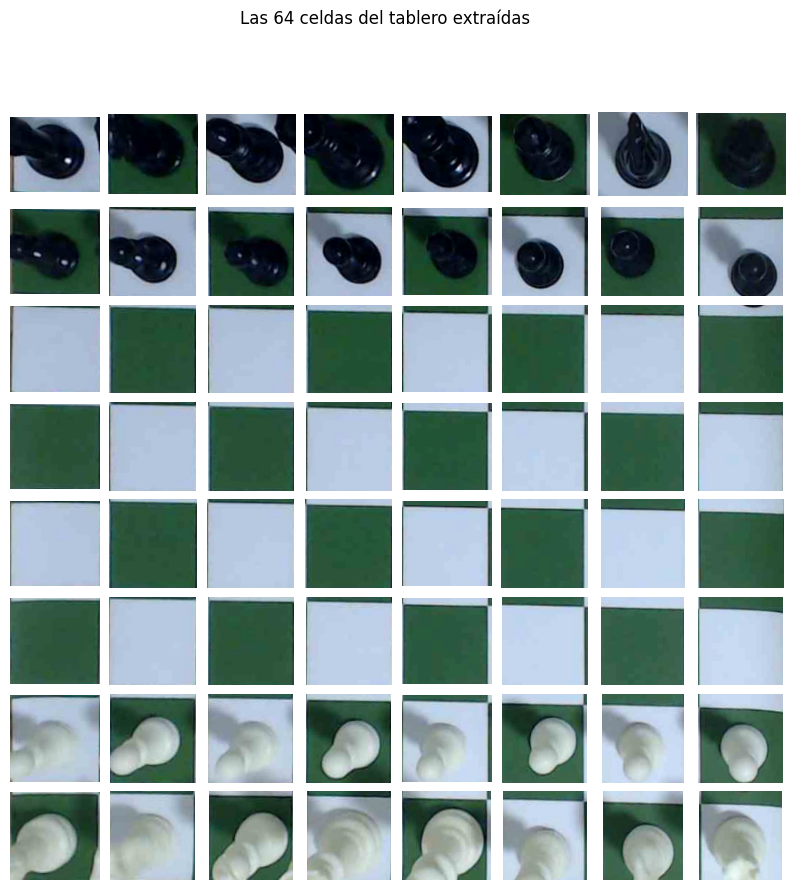

In [18]:
fig, axs = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle("Las 64 celdas del tablero extraídas")

# Iteramos sobre las 8 filas y 8 columnas
for i in range(8):
    for j in range(8):
        # Agarramos las coordenadas de inicio y fin para esta celda
        y1, y2 = int(y_hough[i]), int(y_hough[i+1])
        x1, x2 = int(x_hough[j]), int(x_hough[j+1])
        
        # Recortamos ese pedacito del tablero rectificado (Slicing de Numpy)
        celda = tablero_final_rgb[y1:y2, x1:x2]
        
        # Lo mostramos en la sub-trama correspondiente
        axs[i, j].imshow(celda)
        axs[i, j].axis('off')

# Ajustamos los espacios para que quede prolijo y mostramos
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()